# Демонстрация модели поиска хайлайтов

В этом notebook показана работа обученной модели: загружается сохраненный `.joblib`, заново считаются scores на validation-примерах и predicted windows сравниваются с ground truth windows.

## Что показывает демо

- загружается модель из `outputs/stage2_moment_features/moment_features_highlight_model.joblib`;
- используются CLIP video/text features из `features/clip_features` и `features/clip_text_features`;
- для каждого двухсекундного клипа модель предсказывает вероятность хайлайта;
- соседние клипы выше threshold объединяются во временные интервалы;
- затем сравниваю predicted windows с ground truth windows из QVHighlights.

## Что такое CLIP clip features

В проекте сырые `.mp4` не декодируются во время обучения. Вместо этого используются предрасчитанные Moment-DETR features. В финальном pipeline это CLIP embeddings для видео и текста.

`features/clip_features/<vid>.npz` хранит матрицу размера примерно `(75, 512)`: 75 двухсекундных клипов для 150-секундного видеофрагмента, и каждому клипу соответствует 512-мерный вектор. `features/clip_text_features/qid<id>.npz` хранит 512-мерный embedding текстового запроса.

Если считать такие признаки с нуля, процесс выглядит так: видео разбивается на короткие клипы, из каждого клипа берутся кадры, кадры проходят через visual encoder CLIP, затем frame embeddings агрегируются в один vector для клипа. Текстовый запрос проходит через text encoder CLIP. После этого video и text embeddings находятся в одном пространстве, поэтому можно считать cosine similarity между клипом и запросом. В модели этот similarity используется как один из признаков, а сами CLIP vectors используются как числовое описание содержимого клипа.

In [7]:
from pathlib import Path
import sys

ROOT = Path("/Users/azamath/Desktop/vk_maga/deep_cv/deep-cv")
VENV_SITE = ROOT / ".venv" / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"
if VENV_SITE.exists() and str(VENV_SITE) not in sys.path:
    sys.path.insert(0, str(VENV_SITE))

print("Python:", sys.executable)
print("venv site-packages:", VENV_SITE)

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(ROOT))

from highlight_detection.data import SPLIT_FILES, load_jsonl
from highlight_detection.metrics import build_prediction_summaries, evaluate_clip_predictions
from train_moment_features_model import build_records, compact_for_metrics

MODEL_PATH = ROOT / "outputs" / "stage2_moment_features" / "moment_features_highlight_model.joblib"
DATA_DIR = ROOT / "data" / "qvhighlights"
FEATURE_DIRS = [ROOT / "features" / "clip_features"]
TEXT_FEATURE_DIR = ROOT / "features" / "clip_text_features"

artifact = joblib.load(MODEL_PATH)
model = artifact["model"]
threshold = float(artifact["threshold"])
feature_columns = artifact["feature_columns"]

print(f"Loaded model: {MODEL_PATH.relative_to(ROOT)}")
print(f"Threshold: {threshold:.2f}")
print(f"Numeric feature columns: {len(feature_columns)}")

Python: /Users/azamath/Desktop/vk_maga/deep_cv/deep-cv/.venv/bin/python
venv site-packages: /Users/azamath/Desktop/vk_maga/deep_cv/deep-cv/.venv/lib/python3.12/site-packages
Loaded model: outputs/stage2_moment_features/moment_features_highlight_model.joblib
Threshold: 0.15
Numeric feature columns: 1035


## Проверка формы embeddings

Здесь показаны реальные размеры `.npz` features из проекта. Это помогает объяснить, что модель получает на вход не видеофайл, а уже готовые числовые векторы.

In [8]:
import numpy as np

sample_clip_path = next(FEATURE_DIRS[0].glob("*.npz"))
sample_text_path = next(TEXT_FEATURE_DIR.glob("*.npz"))

clip_npz = np.load(sample_clip_path)
text_npz = np.load(sample_text_path)

print("clip file:", sample_clip_path.name)
print("clip keys:", clip_npz.files)
print("clip features shape:", clip_npz["features"].shape)
print("text file:", sample_text_path.name)
print("text keys:", text_npz.files)
print("text pooler_output shape:", text_npz["pooler_output"].shape)

clip file: MZ1S9oi-zDw_210.0_360.0.npz
clip keys: ['features']
clip features shape: (75, 512)
text file: qid1553.npz
text keys: ['last_hidden_state', 'pooler_output']
text pooler_output shape: (512,)


## Прогон модели на validation subset

Для быстрого демо берутся 40 validation-записей. Это не полный validation protocol из `metrics.json`: финальные метрики считались на 300 validation-записях. Здесь цель другая - показать, что сохраненная модель реально загружается, считает вероятности для клипов и превращает их во временные интервалы.

In [3]:
SAMPLE_ROWS = 40

val_rows = load_jsonl(DATA_DIR / SPLIT_FILES["val"])[:SAMPLE_ROWS]
records = build_records(
    val_rows,
    split="val_demo",
    feature_dirs=FEATURE_DIRS,
    text_feature_dir=TEXT_FEATURE_DIR,
    max_clips=75,
    normalize=True,
)

val_df = pd.DataFrame(records)
scores = model.predict_proba(val_df[["query", *feature_columns]])[:, 1]

scored_records = []
for row, score in zip(records, scores):
    item = dict(row)
    item["score"] = float(score)
    scored_records.append(item)

metric_records = compact_for_metrics(scored_records)
demo_metrics = evaluate_clip_predictions(metric_records, threshold)
pd.DataFrame([demo_metrics]).T.rename(columns={0: "value"})

loading val_demo features: 100%|██████████| 40/40 [00:01<00:00, 31.98video/s]


val_demo: built 2988 clip records; skipped videos without features=0


,value
threshold,0.150000
clip_precision,0.609576
clip_recall,0.733112
clip_f1,0.665661
clip_average_precision,0.641654
segment_precision_iou_0_3,0.156566
segment_recall_iou_0_3,0.525424
segment_f1_iou_0_3,0.241245
segment_precision_iou_0_5,0.106061
segment_recall_iou_0_5,0.355932


## Интерпретация метрик

На этом demo subset модель построила 2988 clip-level примеров из 40 validation-записей. Clip-level метрики получились заметно выше segment-level: `clip_f1` около 0.666, `clip_average_precision` около 0.642. Это значит, что модель в целом умеет ранжировать отдельные двухсекундные клипы по релевантности запросу.

При этом `segment_f1_iou_0_5` около 0.163, а `mean_best_iou` около 0.456. Это ожидаемое ограничение моего baseline: классификатор принимает решение по клипам, а не моделирует всю временную последовательность как Moment-DETR или temporal transformer. Поэтому релевантная область часто находится примерно правильно, но границы интервалов могут быть неточными или фрагментированными.

## Разбор примеров

`mean_best_iou` показывает, насколько близко предсказанные интервалы попали в ground truth. Для защиты верх таблицы используется как набор удачных случаев, а низ таблицы - как примеры ошибок. Это помогает объяснить не только итоговую метрику, но и поведение модели на конкретных запросах.

In [4]:
summaries = build_prediction_summaries(metric_records, threshold, include_gt=True)

summary_table = pd.DataFrame(
    [
        {
            "idx": idx,
            "qid": item["qid"],
            "vid": item["vid"],
            "query": item["query"],
            "predicted_windows": item["predicted_windows"],
            "gt_windows": item["gt_windows"],
            "mean_best_iou": item["mean_best_iou"],
        }
        for idx, item in enumerate(summaries)
    ]
).sort_values("mean_best_iou", ascending=False)

display(summary_table.head(8))
display(summary_table.tail(8))

,idx,qid,vid,query,predicted_windows,gt_windows,mean_best_iou
20,20,4625,RoripwjYFp8_210.0_360.0,A woman wearing glasses eating something at a ...,"[[34.0, 62.0], [104.0, 106.0]]","[[34, 62]]",1.000000
2,2,781,nY42UppPhhg_60.0_210.0,Man talks to the camera while fiddling with hi...,"[[6.0, 20.0], [26.0, 34.0], [36.0, 46.0], [64....","[[6, 20]]",1.000000
36,36,9280,jv7033VUyHE_60.0_210.0,Weather broadcaster updates about tropical for...,"[[0.0, 150.0]]","[[0, 150]]",1.000000
35,35,8783,bP5KfdFJzC4_510.0_660.0,A kid in blue hoodie is sitting with a paper i...,"[[0.0, 144.0]]","[[0, 144]]",1.000000
8,8,2343,r7A-cfBq2Xw_360.0_510.0,Blonde girl talks in her car parked in a lot.,"[[0.0, 44.0], [54.0, 58.0], [80.0, 82.0], [132...","[[0, 46]]",0.956522
21,21,5071,NUsG9BgSes0_60.0_210.0,A woman sitting in front of a desk wearing hea...,"[[90.0, 94.0], [116.0, 136.0]]","[[118, 136]]",0.900000
38,38,10029,pA6Z-qYhSNg_360.0_510.0,Man wearing sunglasses in interviewed next to ...,"[[46.0, 48.0], [52.0, 54.0], [72.0, 74.0], [76...","[[110, 124]]",0.857143
9,9,2579,NUsG9BgSes0_210.0_360.0,A girl and her mother cooked while talking wit...,"[[24.0, 26.0], [48.0, 50.0], [54.0, 56.0], [70...","[[82, 150]]",0.794118


,idx,qid,vid,query,predicted_windows,gt_windows,mean_best_iou
28,28,7484,A_MFAuOwK5k_510.0_660.0,A man cuts watermeoln into small peices on a g...,"[[12.0, 16.0]]","[[4, 22]]",0.222222
14,14,3389,zVwsEVwS8Kw_60.0_210.0,Videographer gives a front eye view of the hot...,"[[108.0, 114.0], [120.0, 122.0], [124.0, 130.0...","[[102, 104], [108, 150]]",0.071429
12,12,3183,YIUaJzjNPuo_360.0_510.0,A woman goes to the 360 Chicago observation de...,"[[56.0, 58.0]]","[[40, 86]]",0.043478
24,24,5926,r7A-cfBq2Xw_60.0_210.0,Woman in parked car holds up a blue water bottle,"[[16.0, 18.0]]","[[0, 14]]",0.000000
32,32,8636,NUsG9BgSes0_660.0_810.0,Woman holds up a green bottle.,[],"[[36, 60]]",0.000000
7,7,2321,r7A-cfBq2Xw_210.0_360.0,A girl opening post office mails in a car,[],"[[40, 90]]",0.000000
18,18,3525,YIUaJzjNPuo_210.0_360.0,A girl doing a selfie video in her night dress,[],"[[26, 50], [56, 80], [86, 92]]",0.000000
26,26,6083,A_MFAuOwK5k_60.0_210.0,Chefs cook the onions alone in a pot.,"[[74.0, 76.0], [96.0, 98.0]]","[[80, 96], [102, 104]]",0.000000


## Интервалы на timeline

На графике синий цвет - ground truth, оранжевый - prediction. Вертикальные серые полосы - top-5 клипов по score. Такой график удобно показывать на защите: сразу видно, попала ли модель в правильную область видео и насколько точно совпали границы.

Good example


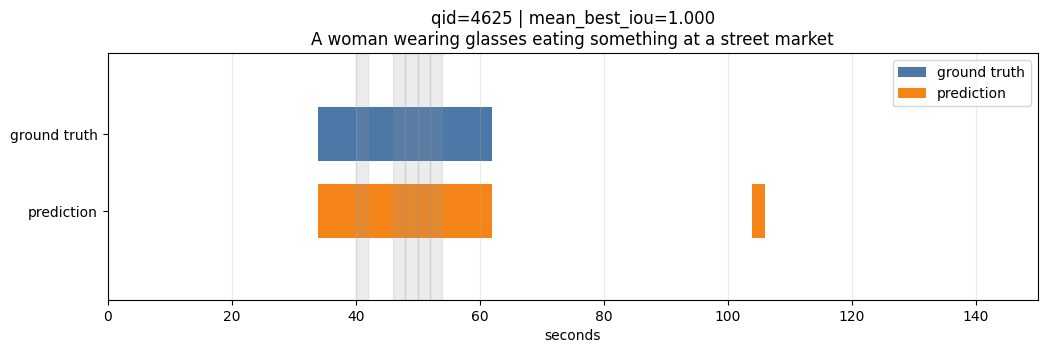

Failure example


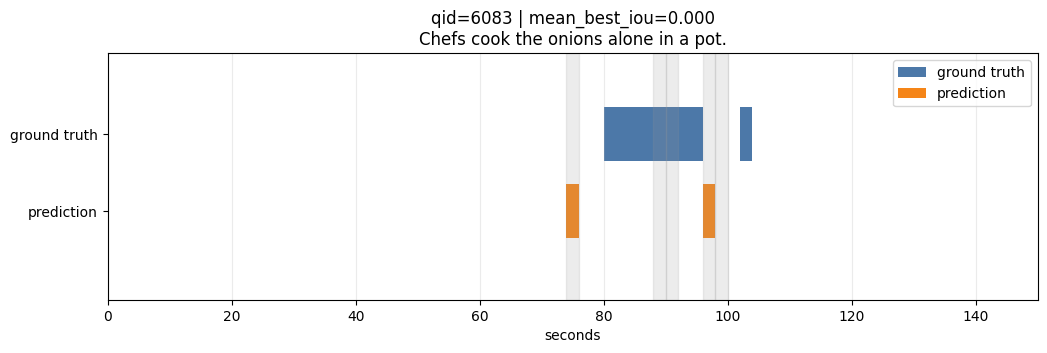

In [5]:
def plot_case(case):
    fig, ax = plt.subplots(figsize=(12, 3.2))

    for start, end in case["gt_windows"]:
        ax.broken_barh([(start, end - start)], (18, 7), facecolors="#4C78A8", label="ground truth")
    for start, end in case["predicted_windows"]:
        ax.broken_barh([(start, end - start)], (8, 7), facecolors="#F58518", label="prediction")
    for clip in case["top_clips"]:
        ax.axvspan(clip["start"], clip["end"], color="#999999", alpha=0.18)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    if unique:
        ax.legend(unique.values(), unique.keys(), loc="upper right")

    ax.set_xlim(0, case["duration"])
    ax.set_ylim(0, 32)
    ax.set_yticks([11.5, 21.5])
    ax.set_yticklabels(["prediction", "ground truth"])
    ax.set_xlabel("seconds")
    ax.set_title(f"qid={case['qid']} | mean_best_iou={case['mean_best_iou']:.3f}\n{case['query']}")
    ax.grid(axis="x", alpha=0.25)
    plt.show()

best_idx = int(summary_table.iloc[0]["idx"])
worst_idx = int(summary_table.iloc[-1]["idx"])

print("Good example")
plot_case(summaries[best_idx])

print("Failure example")
plot_case(summaries[worst_idx])

## Вывод

Я реализовал полный воспроизводимый ML-пайплайн: данные QVHighlights -> CLIP features -> clip-level scores -> объединение клипов в интервалы -> clip-level и segment-level метрики -> анализ ошибок. Сильная сторона решения - оно работает без сырых `.mp4`, использует визуально-текстовые embeddings и быстро запускается на CPU. Слабая сторона - границы интервалов: текущий классификатор принимает решения по клипам почти независимо. Следующий технически логичный шаг - temporal model или более умная постобработка соседних клипов.